# The Attack Path Analysis (APA) Use Case

Following on from the data loading in `loader.ipynb`, this notebook demonstrates how to perform Attack Path Analysis (APA) using Cypher queries on the Neo4j graph database.

In this case we are showing how an attacker could potentially move from single-hop vulnerabilities, to multi-hop lateral movement, and finally to critical "Crown Jewel" assets within an enterprise environment.

In [1]:
from dotenv import load_dotenv
import os
from neo4j import GraphDatabase

load_dotenv()

# Connection details
URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
AUTH = (os.getenv("NEO4J_USER", "neo4j"), os.getenv("NEO4J_PASSWORD", "password"))
DB = os.getenv("NEO4J_DB", "nvd")

# A helper method to run Cypher queries
def run_cypher(query, parameters=None):
    driver = GraphDatabase.driver(URI, auth=AUTH)
    try:
        with driver.session(database=DB) as session:
            result = session.run(query, parameters or {})
            # .data() converts the stream into a list of dictionaries
            return result.data() 
    finally:
        driver.close()

## Identifying the "Front Door" Vulnerability

In this case we are running a query which identifies all internet-facing instances that are vulnerable to known exploited vulnerabilities (KEVs). This represents the "front door" for an attacker to gain initial access into the environment.

In [2]:
import pandas as pd

query = """
MATCH (v:CVE)-[:LISTED_IN]->(:Catalog {name: 'CISA KEV'})
MATCH (v)-[:IDENTIFIED_IN]->(:Library)-[:DEPENDENCY_OF]->(:BuildArtifact)-[:RUNNING_AS]->(app:Application)-[:HOSTED_ON]->(ins:ComputeInstance)
WHERE ins.public_ip IS NOT NULL AND v.baseScore >= 9.0
RETURN v.id AS Recent_CVE, app.name AS Exposed_App, ins.name AS Hostname, ins.public_ip AS IP
"""

results = run_cypher(query)
# Print the results as an html table
df = pd.DataFrame(results)
df

,Recent_CVE,Exposed_App,Hostname,IP
0,CVE-2021-44228,CustomerFacingAPI,api-gateway-01,34.201.1.5
1,CVE-2021-45046,CustomerFacingAPI,api-gateway-01,34.201.1.5


## Analyzing the Blast Radius (Initial Breach)

We can then answer the question "If an attacker compromises this internet-facing instance, what cloud resources can they reach via its identity?"

In [8]:
query = """
MATCH (ins:ComputeInstance {name: 'api-gateway-01'})-[:RUNS_AS]->(id:Identity)
MATCH (id)-[:ASSUMES]->(pol:IAMPolicy)-[:HAS_ACCESS_TO]->(cs:CloudService)
RETURN id.name AS Identity, pol.name AS Policy, cs.resource_name AS Target_Resource
"""

results = run_cypher(query)
df = pd.DataFrame(results)
df

,Identity,Policy,Target_Resource
0,service-account-prod-s3,DataLakeFullAccess,acme-customer-pii-data


## Discovering Lateral Movement Paths to Crown Jewels

We can then explore multi-hop paths from the internet-facing vulnerable instance, through lateral movement opportunities, to critical "Crown Jewel" assets within the environment.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def run_cypher_list(query, parameters=None):
    driver = GraphDatabase.driver(URI, auth=AUTH)
    try:
        with driver.session(database=DB) as session:
            result = session.run(query, parameters or {})
            # Converting to a list consumes the stream but keeps native objects
            return list(result) 
    finally:
        driver.close()

def visualize_attack_paths_nx(query_results):
    if not query_results:
        print("No paths to visualize.")
        return

    G = nx.DiGraph()

    for record in query_results:
        # 'path' is now a native Neo4j Path object
        path = record['path']
        
        # Accessing .nodes and .relationships now works
        for node in path.nodes:
            node_label = list(node.labels)[0] if node.labels else "Unknown"
            node_name = node.get('name') or node.get('id') or "N/A"
            # element_id is the unique identifier for the node in the graph
            G.add_node(node.element_id, label=f"{node_label}\n{node_name}", type=node_label)
            
        for rel in path.relationships:
            port = rel.get('port', '')
            edge_label = f"{rel.type} {port}".strip()
            # Link nodes using the element_id of start and end nodes
            G.add_edge(rel.start_node.element_id, rel.end_node.element_id, label=edge_label)

    # --- Rendering ---
    plt.figure(figsize=(12, 8))
    # Multipartite or Spring layout works well for attack paths
    pos = nx.spring_layout(G, k=1.0) 
    
    # Assign colors based on entity types
    color_map = []
    for node_id in G.nodes():
        n_type = G.nodes[node_id].get('type')
        if n_type == 'ComputeInstance': color_map.append('#3498db') # Blue
        elif n_type == 'Application': color_map.append('#e67e22')   # Orange
        else: color_map.append('#95a5a6')                          # Grey

    nx.draw(G, pos, with_labels=True, 
            labels=nx.get_node_attributes(G, 'label'),
            node_color=color_map, 
            node_size=3500, font_size=8, font_weight='bold', arrows=True)
    
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

    plt.title("Attack Path Analysis: Lateral Movement Visualization")
    plt.show()

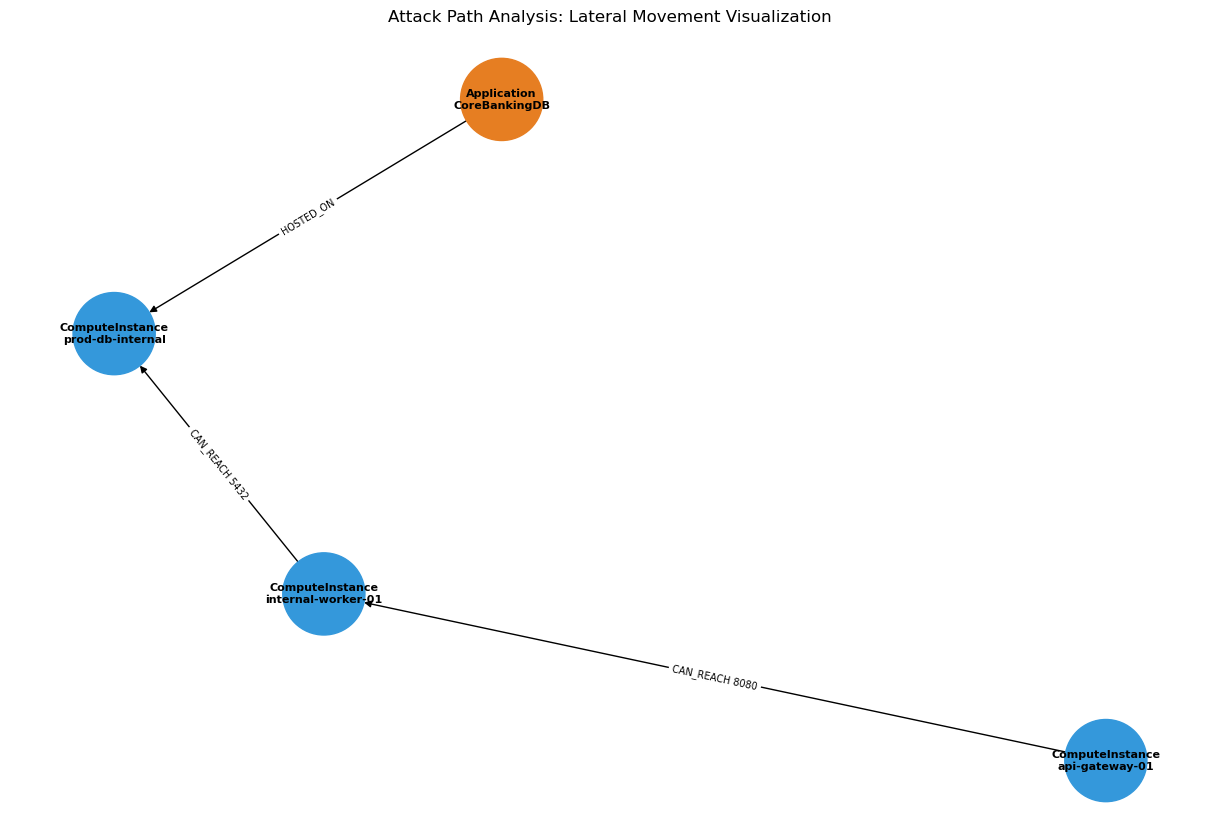

In [4]:
query = """
MATCH (start:ComputeInstance {name: 'api-gateway-01'})
MATCH path = (start)-[:CAN_REACH*1..3]->(target:ComputeInstance)<-[:HOSTED_ON]-(targetApp:Application {tier: 'P0'})
RETURN path
"""
results = run_cypher_list(query)
visualize_attack_paths_nx(results)